# Maternal Stage EF — Pre vs Post (PD1/PD3/PD4) (3-band frequency)

Paper-active dCSFA-NMF model for separating Pre-pup home windows from P1/P3/P4-home windows (3-band frequency resolution).

* Final model: `Maternal_model_TrainC_Pre_P134_Dec19_ver3.pt`
* Hyperparameters from LOO validation (sup_weight=0.025, n_epochs=400, batch_size=512, h=64, seed=2025)
* Stage backproject artifact: `StageEF_3band.xlsx`

In [1]:
# Allow imports from ../src
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt

_repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if os.path.join(_repo_root, "src") not in sys.path:
    sys.path.insert(0, os.path.join(_repo_root, "src"))

from electome.data_utils import create_period_dataset, create_split_dataset, clean_mouse_id
from electome.training import run_loo_cv, train_final_model
from electome.analysis import process_W_nmf_dual_filter
from electome.viz import create_bar_heatmap_selective
from electome.workflow import validate_on_ELS, run_circos_prep, run_stage_backproject
from electome.sara_requests import sara_pup_retrieval

from electome.dCSFA_NMF_Ver1 import dCSFA_NMF as DCSFA_VER1


## Section 1. Data loading and processing

Filter to Pre home / P1 / P3 / P4 home periods. Binary label: `Pre home → 0`, `P1/P3/P4 home → 1`. The C/E split is built via `create_period_dataset` and the `mouse_id` filtering keys are the underscored raw pkl form (e.g. `'C7_ELS11'`).

In [2]:
TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_8Yes/combine/full_spec_features_8roi_Trim_All.pkl"

# Raw mouse_ids with underscores (matches the pkl format)
C_MOUSE_IDS_RAW = ["C7_ELS11", "C2_ELS18", "C5_ELS20", "C7_ELS22",
                    "C1_ELS32", "C5_ELS40", "C6_ELS42", "C7_ELS45"]
E_MOUSE_IDS_RAW = ["E1_ELS33", "E2_ELS3", "E3_ELS37", "E4_ELS39",
                    "E5_ELS41", "E6_ELS44"]

# Cleaned ids for the stage-backproject section
C_MOUSE_IDS = [m.replace("_", "") for m in C_MOUSE_IDS_RAW]
E_MOUSE_IDS = [m.replace("_", "") for m in E_MOUSE_IDS_RAW]

PERIODS_TO_KEEP = ["Pre home", "P1", "P3", "P4 home"]
POSITIVE_PERIODS = ["P1", "P3", "P4 home"]   # mapped to y=1

with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)

base_mask = np.isin(train_dict["period"], PERIODS_TO_KEEP)
base_data = {k: v[base_mask] for k, v in train_dict.items()
             if isinstance(v, np.ndarray) and len(v) == len(train_dict["period"])}

# Binary y from period (Pre home -> 0, P1/P3/P4 home -> 1)
base_y = np.isin(base_data["period"], POSITIVE_PERIODS).astype(np.int64)

# train = all kept periods; held-out tests are computed by period subset on the SAME pkl
train_c     = create_period_dataset(base_data, base_y, C_MOUSE_IDS_RAW, PERIODS_TO_KEEP,   "Train C",      verbose=False)
test_e_all  = create_period_dataset(base_data, base_y, E_MOUSE_IDS_RAW, PERIODS_TO_KEEP,   "Test E (all)", verbose=False)
test_e_post = create_period_dataset(base_data, base_y, E_MOUSE_IDS_RAW, POSITIVE_PERIODS,  "Test E (post)", verbose=False)
test_e_pre  = create_period_dataset(base_data, base_y, E_MOUSE_IDS_RAW, ["Pre home"],      "Test E (Pre)",  verbose=False)

print(f"Train C       : X={train_c['X'].shape}, mice={list(train_c['mouse_list'])}")
print(f"Test E (all)  : X={test_e_all['X'].shape}, mice={list(test_e_all['mouse_list'])}")
print(f"Test E (post) : X={test_e_post['X'].shape}")
print(f"Test E (Pre)  : X={test_e_pre['X'].shape}")


Train C       : X=(65600, 108), mice=['C1ELS32', 'C2ELS18', 'C5ELS20', 'C5ELS40', 'C6ELS42', 'C7ELS11', 'C7ELS22', 'C7ELS45']
Test E (all)  : X=(44000, 108), mice=['E1ELS33', 'E2ELS3', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']
Test E (post) : X=(42800, 108)
Test E (Pre)  : X=(1200, 108)


## Section 2. LOO training

In [3]:
SEED = 2025
N_EPOCHS = 400
N_PRE_EPOCHS = 100
NMF_MAX_ITER = 100
BATCH_SIZE = 512
LR = 0.001

MODEL_PARAMS = {
    "n_components": 10,
    "n_sup_networks": 1,
    "optim_name": "SGD",
    "recon_loss": "MSE",
    "sup_recon_weight": 0.0,
    "sup_weight": 0.025,
    "phi_weight": 0,
    "n_intercepts": 1,
    "useDeepEnc": True,
    "h": 64,
    "sup_recon_type": "Residual",
    "feature_groups": None,
    "group_weights": None,
    "fixed_corr": "Positive",
    "momentum": 0.9,
    "sup_smoothness_weight": 1,
}

loo = run_loo_cv(
    train_c["X"], train_c["y"], train_c["y_intercept"],
    model_params=MODEL_PARAMS,
    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    n_pre_epochs=N_PRE_EPOCHS, nmf_max_iter=NMF_MAX_ITER,
    seed=SEED, n_jobs=4,
    dCSFA_NMF_class=DCSFA_VER1,
)
print(loo.summary())
print()
print(loo.per_mouse_table())


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 100 reached. Increase it to improve convergence.
  warnings.warn(
  0%|          | 0/10 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 100 reached. Increase it to improve convergence.
  warnings.warn(
  0%|          | 0/10 [00:00<?, 

Pretraining NMF...
Identifying predictive components for network 0
Pretraining NMF...
Identifying predictive components for network 0
Pretraining NMF...
Identifying predictive components for network 0
Pretraining NMF...
Identifying predictive components for network 0


  0%|          | 0/100 [00:00<?, ?it/s]

Selecting network: 2 with auc 0.7169357919254659 for sup net 0 using constraint positive correlation
Selecting network: 2 with auc 0.6405763198757763 for sup net 0 using constraint positive correlation
Selecting network: 2 with auc 0.7186894655704008 for sup net 0 using constraint positive correlation
Selecting network: 6 with auc 0.7429357785200411 for sup net 0 using constraint positive correlation


100%|██████████| 100/100 [00:54<00:00,  1.82it/s]
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 100 reached. Increase it to improve convergence.
  warnings.warn(
 30%|███       | 3/10 [00:00<00:00, 28.48it/s]

...


POST-PRETRAIN DIAGNOSTIC
  Recon loss:                    0.028235
  Pred loss (sup_weight × BCE):  0.007501
  Ratio (pred / recon):          0.2657

  ✓ pred_loss is within 2.0× recon_loss, no adjustment needed
  sup_weight for training: 0.025

Pretraining NMF...
Identifying predictive components for network 0


  0%|          | 0/100 [00:00<?, ?it/s]

Selecting network: 2 with auc 0.6834512551759835 for sup net 0 using constraint positive correlation


100%|██████████| 100/100 [00:46<00:00,  2.17it/s]

LOO CV (n=8 mice): AUC = 0.8019 ± 0.0272   Wilcoxon p = 0.003906  ** (p < 0.01)   [wall time 19.4 min]

Mouse        AUC        N        Pos    Neg    phi       
---------------------------------------------------------
C1ELS32      0.7238     9000     8800   200    1.3894    
C2ELS18      0.8257     8600     8400   200    0.6117    
C5ELS20      0.8440     8600     8400   200    1.2173    
C5ELS40      0.7259     9000     8800   200    0.8600    
C6ELS42      0.7087     9000     8800   200    0.9177    
C7ELS11      0.8009     3800     3600   200    0.0355    
C7ELS22      0.8616     8600     8400   200    0.7261    
C7ELS45      0.9248     9000     8800   200    0.3884    


## Section 3. Full training (paper model)

In [4]:
MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_Dec19_ver3.pt"
MODEL_STATE_DICT = "Maternal_sd_TrainC_Pre_P134_Dec19_ver3.pt"

model = train_final_model(
    train_c["X"], train_c["y"], train_c["y_sampling"],
    model_params=MODEL_PARAMS,
    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    n_pre_epochs=N_PRE_EPOCHS, nmf_max_iter=NMF_MAX_ITER,
    seed=SEED,
    save_to=MODEL_SAVE_FILE,
    state_dict_to=MODEL_STATE_DICT,
    dCSFA_NMF_class=DCSFA_VER1,
)
train_aucs = [auc[0] for auc in model.train_auc_hist]
print(f"Paper model saved : {MODEL_SAVE_FILE}")
print(f"  Final train AUC : {train_aucs[-1]:.4f}")


Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 100 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████| 10/10 [00:00<00:00, 30.92it/s]


Selecting network: 2 with auc 0.727051240234375 for sup net 0 using constraint positive correlation


100%|██████████| 100/100 [00:41<00:00,  2.39it/s]



POST-PRETRAIN DIAGNOSTIC
  Recon loss:                    0.026929
  Pred loss (sup_weight × BCE):  0.026560
  Ratio (pred / recon):          0.9863

  ✓ pred_loss is within 2.0× recon_loss, no adjustment needed
  sup_weight for training: 0.025


POST-PRETRAIN DIAGNOSTIC
  Recon loss:                    0.026625
  Pred loss (sup_weight × BCE):  0.003127
  Ratio (pred / recon):          0.1174

  ✓ pred_loss is within 2.0× recon_loss, no adjustment needed
  sup_weight for training: 0.025




POST-PRETRAIN DIAGNOSTIC
  Recon loss:                    0.028294
  Pred loss (sup_weight × BCE):  0.009241
  Ratio (pred / recon):          0.3266

  ✓ pred_loss is within 2.0× recon_loss, no adjustment needed
  sup_weight for training: 0.025




POST-PRETRAIN DIAGNOSTIC
  Recon loss:                    0.025702
  Pred loss (sup_weight × BCE):  0.015125
  Ratio (pred / recon):          0.5885

  ✓ pred_loss is within 2.0× recon_loss, no adjustment needed
  sup_weight for training: 0.025




POST-PRETRAIN DIAGNOSTIC
  Recon loss:                    0.029520
  Pred loss (sup_weight × BCE):  0.005978
  Ratio (pred / recon):          0.2025

  ✓ pred_loss is within 2.0× recon_loss, no adjustment needed
  sup_weight for training: 0.025

Paper model saved : Maternal_model_TrainC_Pre_P134_Dec19_ver3.pt
  Final train AUC : 0.7454


## Section 4. Circos plot

In [5]:
df_circos = run_circos_prep(
    model, train_dict,
    output_csv="StageEF_3band_circos_input.csv",
    k=0, threshold_ratio=0.8,
)


  Circos input written: StageEF_3band_circos_input.csv  (22 features at threshold_ratio=0.8)


## Section 5. Elements selection

absolute intensity range: 0 - 3.684139
relative uniqueness range: 0.0000 - 0.4578


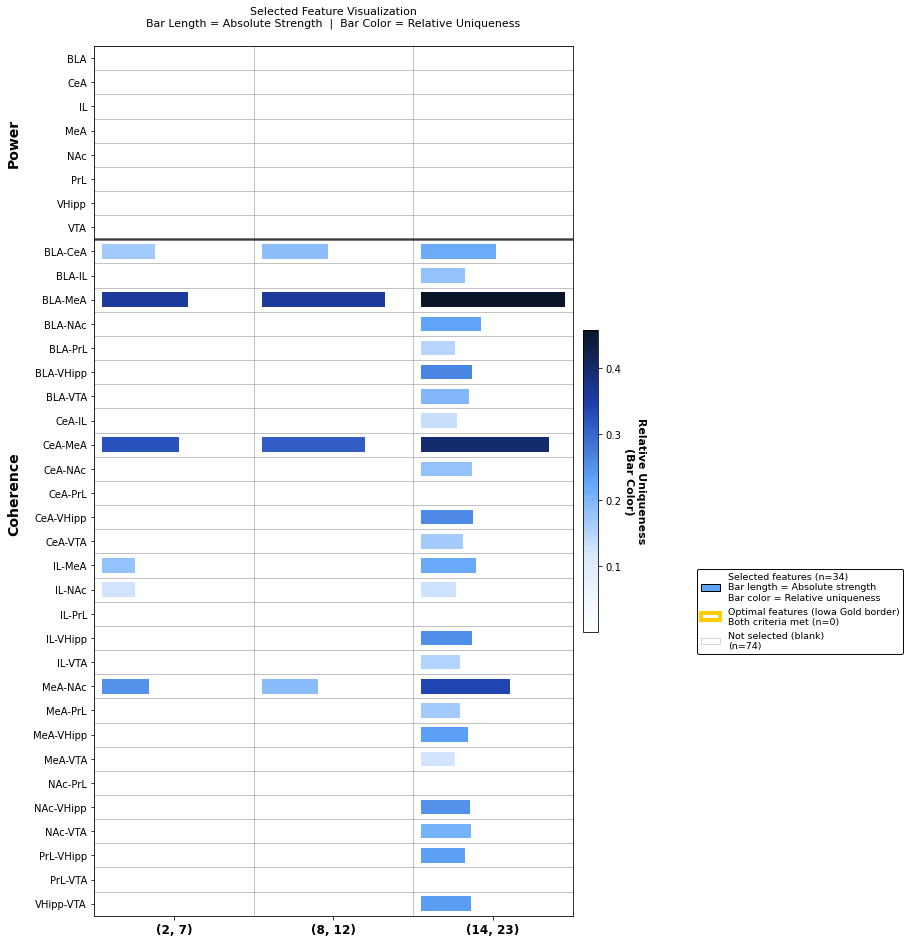

Bar heatmap saved : StageEF_3band_bar_heatmap.png  (0 optimal features)


In [6]:
abs_cut, rel_cut, both_cut, abs_full, rel_full = process_W_nmf_dual_filter(
    model.get_W_nmf(), train_dict,
    abs_cum_ratio=0.9, rel_val=0.5,
    verbose=False,
)
fig = create_bar_heatmap_selective(abs_full, abs_cut, rel_full, rel_cut, both_cut)
fig.savefig("StageEF_3band_bar_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Bar heatmap saved : StageEF_3band_bar_heatmap.png  "
      f"({(~both_cut.isna()).sum().sum()} optimal features)")


## Section 6. Validation on ELS group

In [7]:
els = validate_on_ELS(model, {
    "E mice (all PD periods)": test_e_all,
    "E mice (post = P1/P3/P4)": test_e_post,
    "E mice (Pre home only)":  test_e_pre,
})
print(els.summary())


VALIDATION ON ELS GROUP
  E mice (all PD periods): AUC = 0.7702 ± 0.0742  (n=6 mice)   Wilcoxon p = 0.01562  *
  E mice (post = P1/P3/P4): AUC = nan ± nan  (n=0 mice)   Wilcoxon p = nan  n/a
  E mice (Pre home only): AUC = nan ± nan  (n=0 mice)   Wilcoxon p = nan  n/a


## Section 8. Additional backprojections (Sara's request)

In [8]:
PUP_RETRIEVAL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P4_pup_retrieval_detail.pkl"

sara_pup_retrieval(
    model,
    pup_retrieval_data_file=PUP_RETRIEVAL_DATA_FILE,
    c_mouse_ids=["C6ELS9"] + C_MOUSE_IDS,
    e_mouse_ids=E_MOUSE_IDS,
    output_xlsx="StageEF_3band_pups.xlsx",
)


  Sara pup retrieval written: StageEF_3band_pups.xlsx  (9 mice, Individual + Summary sheets)
